In [1]:
# import galstreams
# mws = galstreams.MWStreams(verbose=False)

import sys, pickle, os
from importlib import reload
from tqdm import tqdm, trange

import numpy as np, pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm

import agama 
Gyr_to_AgamaTime = 1.0227 # 1 Gyr in Agama time units (kpc/(km/s))
import nbody_streams.agama_helper as ah

import emcee
import corner

from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import Galactocentric, ICRS, CartesianDifferential, CartesianRepresentation
from astropy import table

In [2]:
sys.path.append('../scripts/')
from coordinate_utils import get_rotation_matrix, sf_to_icrs, icrs_to_sf
from generate_sim_stream import create_stream_particle_spray
from stream_likelihood import log_likelihood, make_spline, log_prior, log_probability
from stream_data_utils import read_in_data

In [3]:
jet_member_path = '../data/jet_members.csv'

jet_table = pd.read_csv(jet_member_path)

df_jet, distance_fit_jet, prog_pars_jet, prog_pars_icrs_jet = read_in_data(jet_table, 'bhb_dist')

In [4]:
data_dict_jet = dict(
    phi1_obs = df_jet['phi1'].values,
    phi2_obs = df_jet['phi2'].values,
    rv_obs = df_jet['vel_calib'].values,
    rv_obs_errors = df_jet['vel_calib_std'].values,
    dist_obs = df_jet['bhb_dist'].values,
    dist_obs_errors = (df_jet['bhb_dist'].values*0.1),
    pmra_cosdec_obs = df_jet['pmra'].values,
    pmra_cosdec_obs_errors = df_jet['pmra_error'].values,
    pmdec_obs = df_jet['pmdec'].values,
    pmdec_obs_errors = df_jet['pmdec_error'].values,
)

In [5]:
BASE_POT_PATH = '../potential_files/'
potMW_path = os.path.join(BASE_POT_PATH, 'base_mw_pot.ini')
## potential models to load
basePot = agama.Potential(file=potMW_path)
scaleNFW_half = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.5, 1],[0, 1, 1]])
potHalf= basePot + scaleNFW_half
NFW = agama.Potential(type= 'NFW', mass = 5.5427e11, scaleRadius = 15.626)
potStat = basePot + NFW
#pot_spheroid.density([10, 0, 0], t=0), pot_spheroid.density([10, 0, 0], t=-5)
#pot_spheroid = agama.Potential(type='spheroid', mass=1e12, scaleradius=20, scale=[[-5, 0.5, 1],[0, 1, 1]])

Running 50 streams...
  50/50
Done.
Saved → mcmc_progenitor_samples.gif


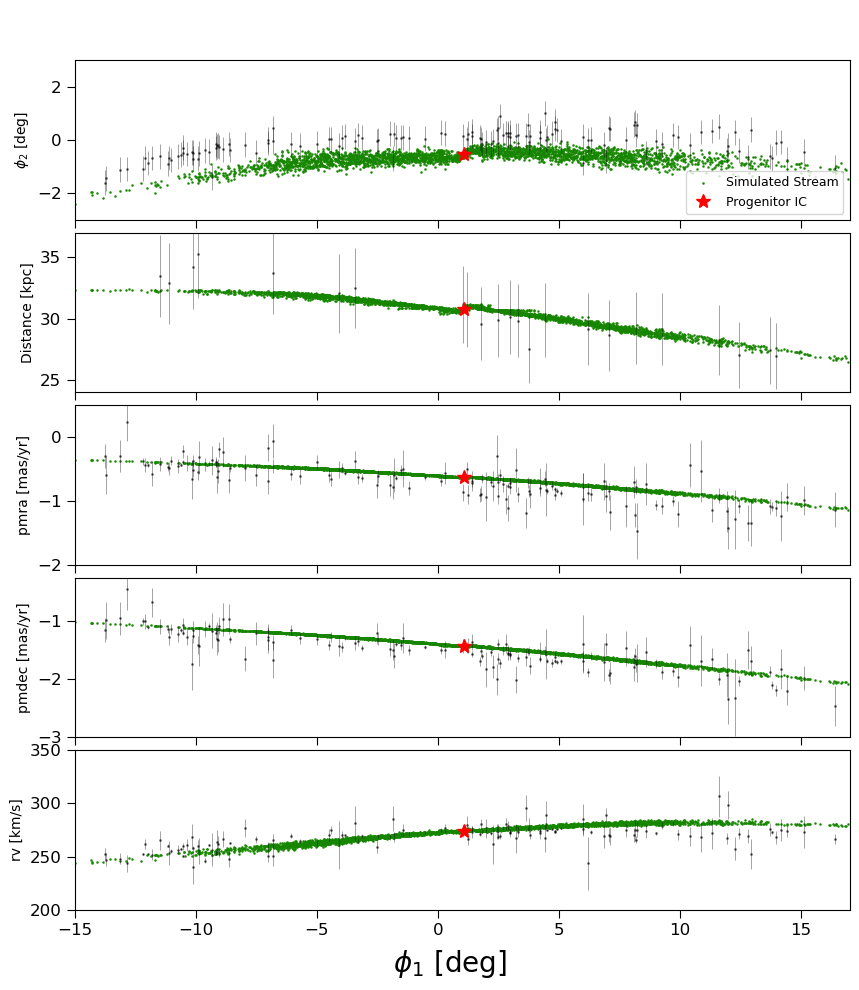

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import astropy.coordinates as coord
import astropy.units as u

# ── 1. Setup ──────────────────────────────────────────────────────────────────
R = np.array([[-0.69533693,  0.61240175, -0.37612584],
              [-0.62909984, -0.26561497,  0.73053548],
              [ 0.34747655,  0.744589,    0.56995374]])
jet_rot_matrix = u.Quantity(R, unit=u.dimensionless_unscaled)

prog_mass        = 20_000
prog_scaleradius = 10/1_000
num_particles    = 3_000
Age_stream_inGyr = 5.0

best_fit = np.array([0, 0.15, 30.08, -0.64, -1.46, 272.41])
sigmas   = np.array([3.0, 1.0, 0.8, 0.05, 0.05, 3.0])  # tune to your posterior widths

np.random.seed(42)
n_samples = 50
samples = best_fit + np.random.randn(n_samples, 6) * sigmas


# ── 2. Jet → Galactocentric ───────────────────────────────────────────────────
def prog_pars_to_galactocentric(prog_pars):
    phi1, phi2, dist, pmra, pmdec, rv = prog_pars
    ra, dec = sf_to_icrs(phi1, phi2, jet_rot_matrix)

    jet_c = coord.SkyCoord(
        ra=ra*u.degree, dec=dec*u.degree, distance=dist*u.kpc,
        pm_ra_cosdec=pmra*u.mas/u.yr,
        pm_dec=pmdec*u.mas/u.yr,
        radial_velocity=rv*u.km/u.s
    )
    rep = jet_c.transform_to(coord.Galactocentric)
    return np.array([
        rep.x.value, rep.y.value, rep.z.value,
        rep.v_x.value, rep.v_y.value, rep.v_z.value
    ])


# ── 3. Run stream ─────────────────────────────────────────────────────────────
def run_stream(prog_pars):
    prog_wtoday_gal = prog_pars_to_galactocentric(prog_pars)
    return create_stream_particle_spray(
        pot_host=potStat,
        initmass=prog_mass,
        scaleradius=prog_scaleradius,
        prog_pot_kind='Plummer',
        sat_cen_present=prog_wtoday_gal,
        num_particles=num_particles,
        time_end=0.0,
        time_total=Age_stream_inGyr,
        save_rate=1,
    )


# ── 4. Extract observables ────────────────────────────────────────────────────
def extract_observables(stream):
    part_xv = stream['part_xv']  # (n_particles, 6), squeeze save_rate dim

    galcen = coord.Galactocentric(
        x=part_xv[:, 0] * u.kpc,
        y=part_xv[:, 1] * u.kpc,
        z=part_xv[:, 2] * u.kpc,
        v_x=part_xv[:, 3] * u.km/u.s,
        v_y=part_xv[:, 4] * u.km/u.s,
        v_z=part_xv[:, 5] * u.km/u.s,
        representation_type='cartesian',
        differential_type='cartesian'
    )

    icrs = galcen.transform_to(coord.ICRS())
    phi1, phi2 = icrs_to_sf(icrs.ra.value, icrs.dec.value, jet_rot_matrix)

    return (phi1, phi2,
            icrs.distance.value,
            icrs.pm_ra_cosdec.value,
            icrs.pm_dec.value,
            icrs.radial_velocity.value)


# ── 5. Pre-run all 50 streams ─────────────────────────────────────────────────
print("Running 50 streams...")
all_streams = []
for i, prog in enumerate(samples):
    print(f"  {i+1}/{n_samples}", end='\r')
    stream = run_stream(prog)
    all_streams.append(extract_observables(stream))
print("\nDone.")


# ── 6. Build figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(10, 10))
fig.supxlabel(r'$\phi_1$ [deg]', fontsize=20)
plt.subplots_adjust(top=0.93, bottom=0.08, hspace=0.08)

ylims   = [(-3, 3), (24, 37), (-2, 0.5), (-3, -0.25), (200, 350)]
ylabels = [r'$\phi_2$ [deg]', 'Distance [kpc]',
           'pmra [mas/yr]', 'pmdec [mas/yr]', 'rv [km/s]']

for ax, yl, ylabel in zip(axes, ylims, ylabels):
    ax.set_ylim(*yl)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=12, length=6)
axes[-1].set_xlim(-15, 17)

#Observed data (fixed background) — uncomment when df is available
for ax, ycol, yerr in zip(axes, 
    ['phi2', 'bhb_dist', 'pmra', 'pmdec', 'vel_calib'],
    [np.nanstd(df_jet['phi2']), df_jet['bhb_dist']*0.1,
     df_jet['pmra_error'], df_jet['pmdec_error'], df_jet['vel_calib_std']]):
    ax.scatter(df_jet['phi1'], df_jet[ycol], s=1, color='k', alpha=0.5)
    ax.errorbar(df_jet['phi1'], df_jet[ycol], yerr=yerr,
                fmt='none', ecolor='k', alpha=0.5, capsize=0, elinewidth=0.5)

# Animated artists
sim_artists = [ax.scatter([], [], s=0.75, color='#168600', alpha=0.9)
               for ax in axes]
prog_markers = [ax.plot([], [], '*', color='red', ms=10, zorder=5)[0]
                for ax in axes]
axes[0].legend(handles=[sim_artists[0], prog_markers[0]],
               labels=['Simulated Stream', 'Progenitor IC'],
               loc='lower right', fontsize=9)

title = fig.suptitle('', fontsize=11)


# ── 7. Animation update ───────────────────────────────────────────────────────
def update(frame):
    phi1, phi2, dist, pmra, pmdec, rv = all_streams[frame]
    prog = samples[frame]

    for artist, ydata in zip(sim_artists, [phi2, dist, pmra, pmdec, rv]):
        artist.set_offsets(np.c_[phi1, ydata])

    # progenitor value per panel: [phi2, dist, pmra, pmdec, rv]
    prog_vals = [prog[1], prog[2], prog[3], prog[4], prog[5]]
    for marker, yval in zip(prog_markers, prog_vals):
        marker.set_data([prog[0]], [yval])

    title.set_text(
        f'Sample {frame+1}/{n_samples} | '
        f'φ₁={prog[0]:.2f}  φ₂={prog[1]:.2f}  d={prog[2]:.2f} kpc  '
        f'μα={prog[3]:.3f}  μδ={prog[4]:.3f}  rv={prog[5]:.1f} km/s'
    )
    return sim_artists + prog_markers + [title]


# ── 8. Render & save ──────────────────────────────────────────────────────────
ani = animation.FuncAnimation(fig, update, frames=n_samples,
                               interval=300, blit=True)

ani.save('mcmc_progenitor_samples.gif', writer='pillow', dpi=100, fps=4)
print("Saved → mcmc_progenitor_samples.gif")
plt.show()

In [11]:
stream = run_stream(samples[0])
print(type(stream))
print(stream.keys() if hasattr(stream, 'keys') else dir(stream))

<class 'dict'>
dict_keys(['times', 'prog_xv', 'part_xv'])
